<p align = "center" text> <b>Algorithm Implementation</b></p>

In [1]:
def algorithm_2(A):
    compute(A)
    dump(A)

In [2]:
import math
from collections import deque
def compute(A):
    """Sorts the array using a 2-pass Radix sort (base sqrt(N))."""
    N = len(A)
    if N == 0:
        return
        
    # size <- [\sqrt{N}] + 1
    size = int(math.sqrt(N)) + 1
    
    # Z[1..size] <- EmptyList
    # Using deque to simulate linked lists for O(1) removals from the front
    Z = [deque() for _ in range(size)]
    
    # --- FIRST PASS: Sort by least significant "digit" ---
    for i in range(N):
        Z[A[i] % size].append(A[i])
        
    counter = 0
    for i in range(size):
        while Z[i]: # while Z[i] is not empty
            A[counter] = Z[i].popleft() # FirstElement + DeleteFirstElement
            counter += 1
            
    # --- SECOND PASS: Sort by most significant "digit" ---
    for i in range(N):
        # Note: This will raise an IndexError if A[i] >= size^2
        Z[A[i] // size].append(A[i])
        
    counter = 0
    for i in range(size):
        while Z[i]:
            A[counter] = Z[i].popleft()
            counter += 1

In [3]:
def dump(A):
    """Prints the elements of the array."""
    for val in A:
        print(val)

<p align = "center" text> <b>Algorithm Description</b></p>

Algorithm 2 is a specialized, non-comparison-based sorting algorithm. Specifically, it is a variant of Radix Sort designed to sort an array A of $N$ integers in linear time. Instead of using base-10, the algorithm dynamically calculates a base relative to the number of elements in the array:$$b = \lfloor\sqrt{N}\rfloor + 1$$
 Any integer x can be represented in this base b using two "digits":
1. Least Significant Digit: $x \bmod b$
2. Most Significant Digit: $x \div b$ (integer division)

**Step-by-Step Execution**   

 1. **Initialization**: The algorithm calculates the size ($b$) and creates an array Z containing size empty linked lists (acting as buckets).
 2. **First Pass (Distribution)**: It iterates through the array A and places each element into a bucket in Z based on its least significant digit (A[i] % size).
 3. **First Pass (Collection)**: It traverses the buckets in Z in order, removing elements from the front of the linked lists and placing them back into A. The array is now partially sorted.
 4. **Second Pass (Distribution)**: It iterates through the updated array A and places each element into a bucket in Z based on its most significant digit (A[i] / size).
 5. **Second Pass (Collection)**: It again traverses Z, moving elements back into A. The array is now fully sorted.

**Limitation**: Because it only performs exactly two passes, this algorithm assumes that every element in the array is strictly less than $\text{size}^2$ (which is approximately $N$). If an element is larger, the second pass will attempt to access an index outside the bounds of Z.



<p align = "center" text> <b>Time Complexity Analysis</b></p>  
Since Algorithm 2 is a non comparison based algorithm, it's therefore not limited by the expected $\Omega(N \log N)$ that algorithms such as **mergesort** is limited to.  

**Expected Time**  
Initalization $\rightarrow$ $O(\sqrt{N})$  
Pass 1: Distribute $\rightarrow$ $O(N)$  
Pass 1: Collect $\rightarrow$ $O(N + \sqrt{N})$  
Pass 2: Distribute $\rightarrow$ $O(N)$  
Pass 2: Collect $\rightarrow$ $O(N + \sqrt{N})$  

**Overall Time Complexity**:   

$\Theta(N)$ To find the total time complexity, we sum the phases:$$T(N) = O(\sqrt{N}) + O(N) + O(N + \sqrt{N}) + O(N) + O(N + \sqrt{N})$$

**Best Case vs. Worst Case** 

Best Case: $\Theta(N)$   
Worst Case: $\Theta(N)$


<p align = "center" text> <b>Benchmark and Conclusion</b></p>

In [4]:
import time
import random
import matplotlib.pyplot as plt
def benchmark():
    # Problem sizes to test
    sizes = [100, 500, 1000, 5000, 10000, 50000, 100000]
    replications = 15 # Average out background OS noise
    random_times = []
    sorted_times = []
    reversed_times = []
    print(f"{'Size (N)':<12} | {'Random (s)':<12} | {'Sorted (s)':<12} | {'Reversed (s)':<12}")
    print("-" * 55)
    
    for N in sizes:
        times = {"Random": 0, "Sorted": 0, "Reversed": 0}
        
        for _ in range(replications):
            # Generate valid data (must be < size^2)
            max_val = N - 1 
            
            # Create test arrays
            arr_sorted = list(range(max_val + 1))
            arr_reversed = arr_sorted[::-1]
            arr_random = arr_sorted[:]
            random.shuffle(arr_random)
            
            # Time Random
            start = time.perf_counter()
            compute(arr_random)
            times["Random"] += time.perf_counter() - start
            
            # Time Sorted
            start = time.perf_counter()
            compute(arr_sorted)
            times["Sorted"] += time.perf_counter() - start
            
            # Time Reversed
            start = time.perf_counter()
            compute(arr_reversed)
            times["Reversed"] += time.perf_counter() - start
            
        # Calculate averages
        avg_rand = times["Random"] / replications
        avg_sort = times["Sorted"] / replications
        avg_rev = times["Reversed"] / replications
        
        print(f"{N:<12} | {avg_rand:<12.5f} | {avg_sort:<12.5f} | {avg_rev:<12.5f}")
        random_times.append(avg_rand)
        sorted_times.append(avg_sort)
        reversed_times.append(avg_rev)



    print("\nGenerating plot...")
    plt.figure(figsize=(10, 6))
        
    plt.plot(sizes, random_times, marker='o', color='blue', label='Random Data')
    plt.plot(sizes, sorted_times, marker='s', color='green', label='Sorted Data')
    plt.plot(sizes, reversed_times, marker='^', color='red', label='Reversed Data')
        
    plt.title("Execution Time vs. Array Size (O(N))", fontsize=14)
    plt.xlabel("Array Size (N)", fontsize=12)
    plt.ylabel("Execution Time (Seconds)", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ticklabel_format(style='plain', axis='x') # Stops scientific notation like 1e6
        
        # Save the file and display it
    plt.tight_layout()
    plt.savefig("algorithm_runtime_plot.png", dpi=300)
    plt.show()

Size (N)     | Random (s)   | Sorted (s)   | Reversed (s)
-------------------------------------------------------
100          | 0.00003      | 0.00003      | 0.00003     
500          | 0.00016      | 0.00016      | 0.00015     
1000         | 0.00031      | 0.00031      | 0.00031     
5000         | 0.00153      | 0.00154      | 0.00153     
10000        | 0.00297      | 0.00295      | 0.00292     
50000        | 0.01839      | 0.01603      | 0.01628     
100000       | 0.03724      | 0.02996      | 0.03098     

Generating plot...


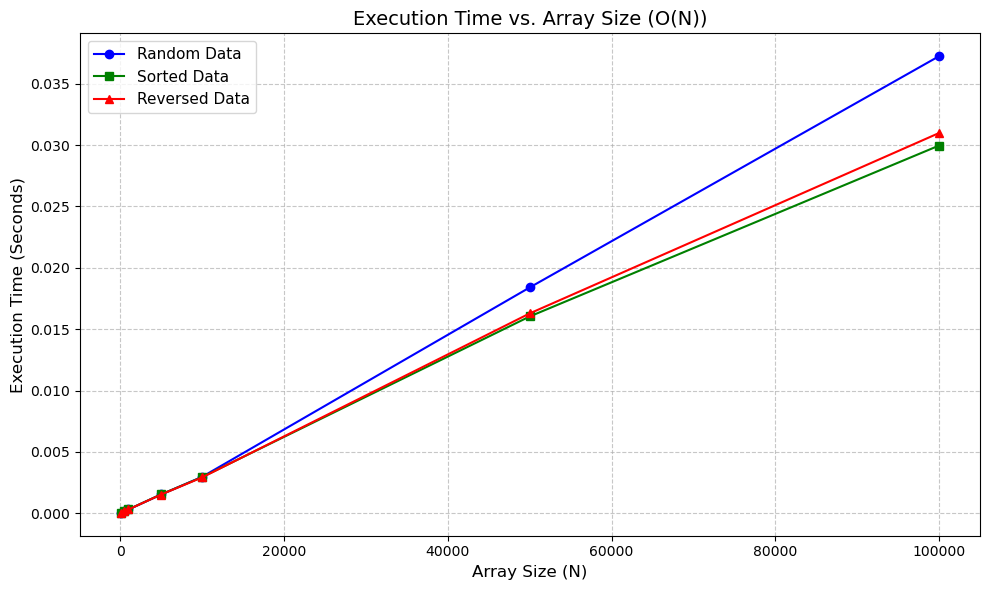

In [5]:
benchmark()